<a href="https://colab.research.google.com/github/Everlovek/TCS-iON-135-Predictive-Modeling-of-Credit-Scores-Through-Logistic-Regression/blob/main/Predictive_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark --quiet
print("PySpark installed")

PySpark installed


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, shutil, time
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, udf
from pyspark.sql.types import FloatType
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, ConfusionMatrixDisplay
)
print("All libraries imported")

All libraries imported


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_FOLDER = '/content/drive/MyDrive/Colab Notebooks/CreditScoreProject'
os.makedirs(PROJECT_FOLDER, exist_ok=True)
print(f"Project folder ready: {PROJECT_FOLDER}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder ready: /content/drive/MyDrive/Colab Notebooks/CreditScoreProject


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/CreditScoreProject/cs-training.csv')
print("Train shape:", df.shape)

# SparkSession CREATION
if 'spark' in locals() and spark.sparkContext._jsc is not None: # Check if spark exists and is active
    spark.stop()

spark = SparkSession.builder \
    .appName("CreditScorePrediction") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")
print(f"Spark {spark.version} started!")

Train shape: (150000, 12)
Spark 4.0.2 started!


In [ ]:
print(f"  Rows    : {df.shape[0]:,}  (number of borrowers)")
print(f"  Columns : {df.shape[1]}     (pieces of info per borrower)")
print()
print("First 5 rows:")
df.head()

  Rows    : 150,000  (number of borrowers)
  Columns : 12     (pieces of info per borrower)

First 5 rows:


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
column_descriptions = {
    'SeriousDlqin2yrs'                    : 'TARGET — 1=defaulted, 0=did not default',
    'RevolvingUtilizationOfUnsecuredLines' : 'Credit card usage ratio (0.5 = using 50% of limit)',
    'age'                                  : 'Age of the borrower in years',
    'NumberOfTime30-59DaysPastDueNotWorse' : 'Times 30-59 days late on a payment',
    'DebtRatio'                            : 'Monthly debt / Monthly income',
    'MonthlyIncome'                        : 'Monthly income of the borrower (dollars)',
    'NumberOfOpenCreditLinesAndLoans'      : 'Total open loans and credit lines',
    'NumberOfTimes90DaysLate'              : 'Times 90+ days late on a payment',
    'NumberRealEstateLoansOrLines'         : 'Number of mortgages or real estate loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Times 60-89 days late on a payment',
    'NumberOfDependents'                   : 'Number of family members depending on borrower'
}
print(f"{'Column':<45} {'Meaning'}")
print("-" * 90)
for k, v in column_descriptions.items():
    print(f"{k:<45} {v}")

Column                                        Meaning
------------------------------------------------------------------------------------------
SeriousDlqin2yrs                              TARGET — 1=defaulted, 0=did not default
RevolvingUtilizationOfUnsecuredLines          Credit card usage ratio (0.5 = using 50% of limit)
age                                           Age of the borrower in years
NumberOfTime30-59DaysPastDueNotWorse          Times 30-59 days late on a payment
DebtRatio                                     Monthly debt / Monthly income
MonthlyIncome                                 Monthly income of the borrower (dollars)
NumberOfOpenCreditLinesAndLoans               Total open loans and credit lines
NumberOfTimes90DaysLate                       Times 90+ days late on a payment
NumberRealEstateLoansOrLines                  Number of mortgages or real estate loans
NumberOfTime60-89DaysPastDueNotWorse          Times 60-89 days late on a payment
NumberOfDependents        

In [ ]:
# Summary statistics for every column
# count=non-missing rows, mean=average, std=spread, min/max=range
print("Summary statistics:")
df.describe().T.round(2)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,150000.0,75000.50,43301.41,1.0,37500.75,75000.50,112500.25,150000.0
SeriousDlqin2yrs,150000.0,0.07,0.25,0.0,0.00,0.00,0.00,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.05,249.76,0.0,0.03,0.15,0.56,50708.0
age,150000.0,52.30,14.77,0.0,41.00,52.00,63.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.42,4.19,0.0,0.00,0.00,0.00,98.0
DebtRatio,150000.0,353.01,2037.82,0.0,0.18,0.37,0.87,329664.0
MonthlyIncome,120269.0,6670.22,14384.67,0.0,3400.00,5400.00,8249.00,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.45,5.15,0.0,5.00,8.00,11.00,58.0
NumberOfTimes90DaysLate,150000.0,0.27,4.17,0.0,0.00,0.00,0.00,98.0
NumberRealEstateLoansOrLines,150000.0,1.02,1.13,0.0,0.00,1.00,2.00,54.0


Not Defaulted (0): 139,974 (93.3%)
Defaulted     (1): 10,026 (6.7%)
Class imbalance ratio: 1 : 13


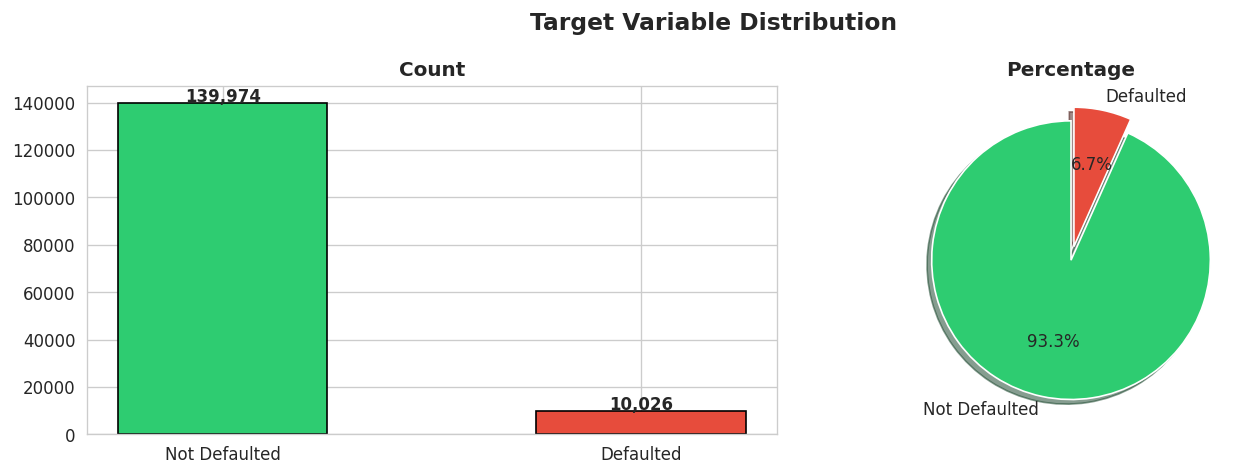

Chart saved to Google Drive.


In [ ]:
counts = df['SeriousDlqin2yrs'].value_counts()
pct    = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

print(f"Not Defaulted (0): {counts[0]:,} ({pct[0]:.1f}%)")
print(f"Defaulted     (1): {counts[1]:,} ({pct[1]:.1f}%)")
print(f"Class imbalance ratio: 1 : {int(counts[0]/counts[1])}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')

bars = axes[0].bar(['Not Defaulted', 'Defaulted'], counts.values,
                   color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Count', fontweight='bold')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+500, f'{v:,}',
                 ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Not Defaulted','Defaulted'],
            autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'],
            startangle=90, explode=(0, 0.1), shadow=True)
axes[1].set_title('Percentage', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_class_distribution.png', bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive.")

Missing values per column:
                    Count  Percent
MonthlyIncome       29731    19.82
NumberOfDependents   3924     2.62


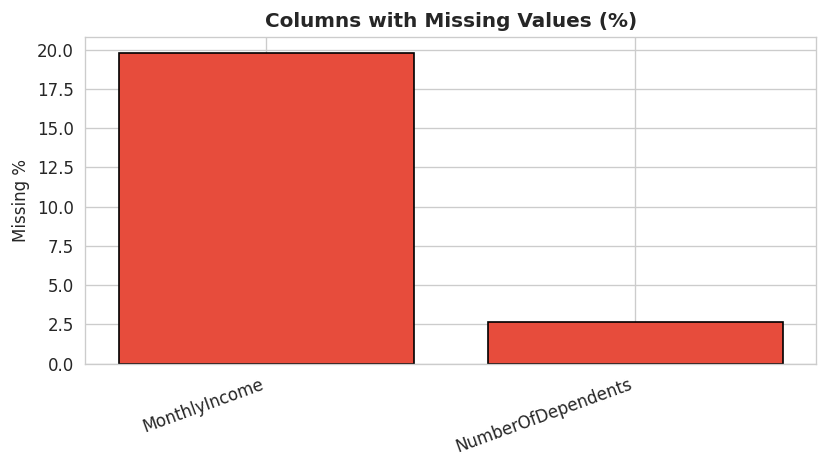

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct.round(2)})

print("Missing values per column:")
print(missing_df[missing_df['Count'] > 0].to_string())

missing_only = missing_df[missing_df['Count'] > 0]
plt.figure(figsize=(7, 4))
plt.bar(missing_only.index, missing_only['Percent'],
        color='#e74c3c', edgecolor='black')
plt.title('Columns with Missing Values (%)', fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_missing_values.png', bbox_inches='tight')
plt.show()

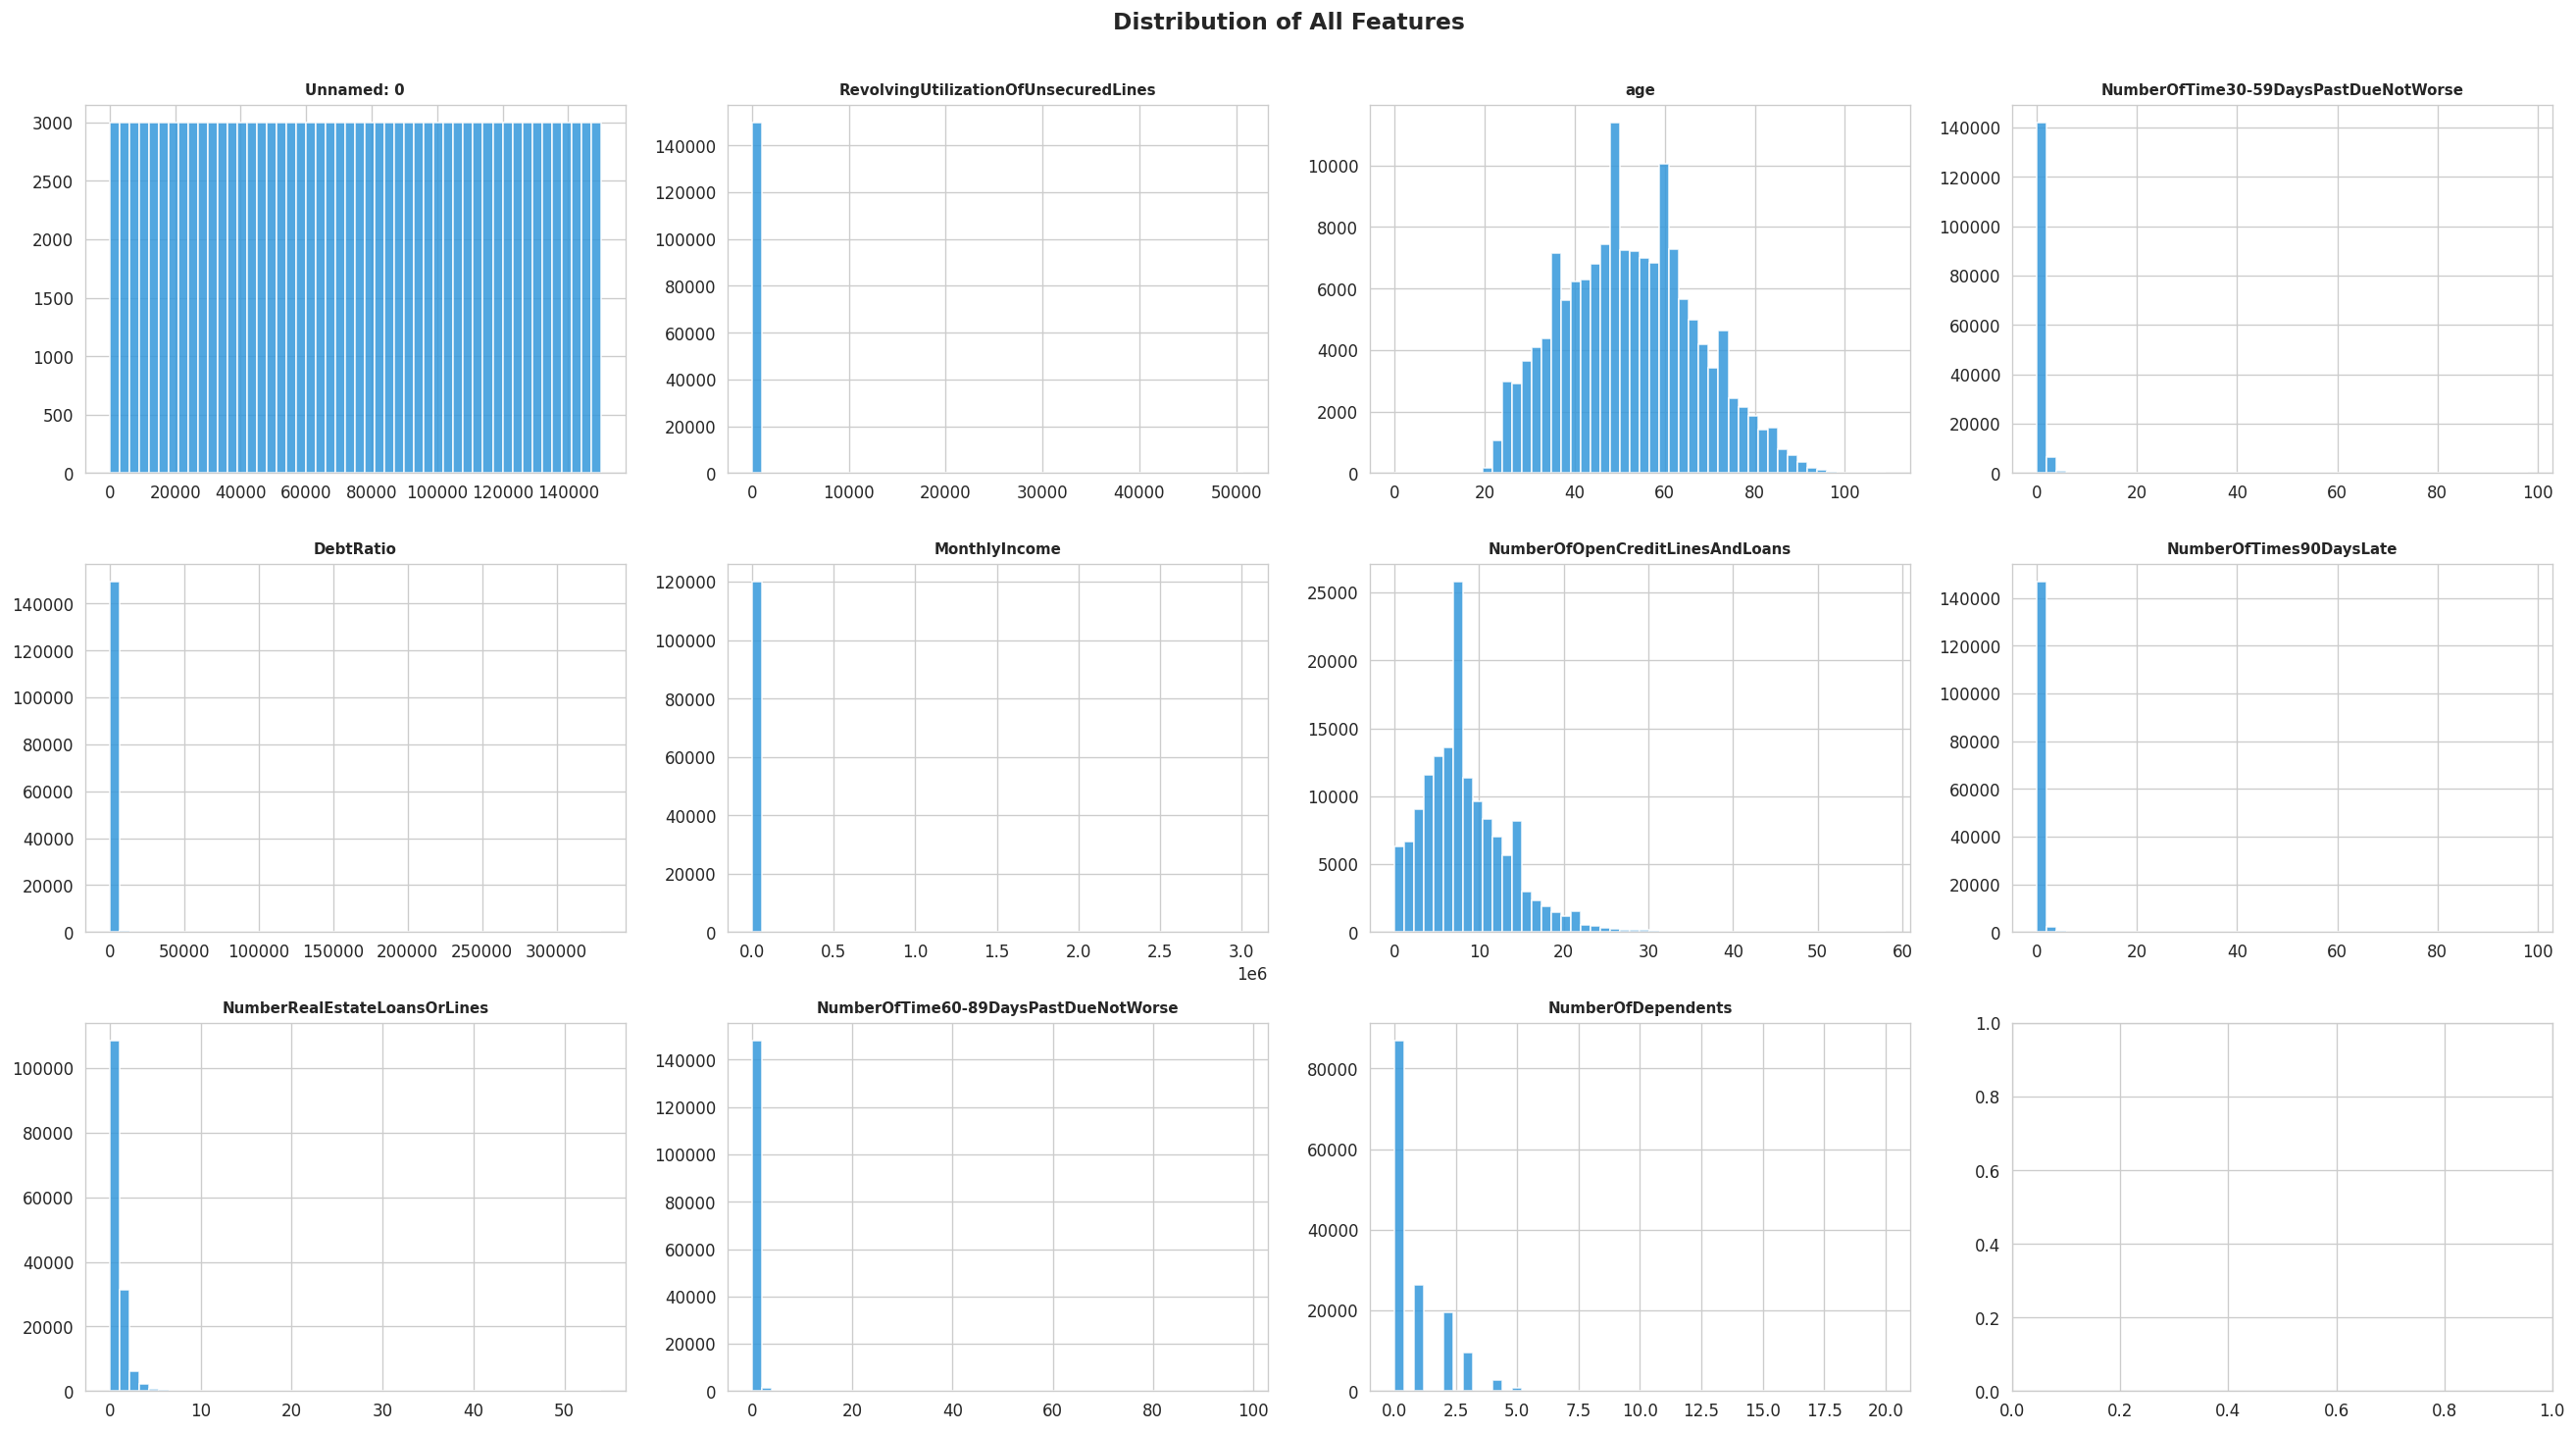

Chart saved to Google Drive.


In [ ]:
features = [c for c in df.columns if c != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(3, 4, figsize=(22, 12)) # Changed to 3 rows, 4 columns for 12 plots
axes = axes.flatten()
for i, feat in enumerate(features):
    if i < len(axes): # Added a check to ensure index is within bounds
        axes[i].hist(df[feat].dropna(), bins=50,
                     color='#3498db', edgecolor='white', alpha=0.85)
        axes[i].set_title(feat, fontsize=9, fontweight='bold')
    else:
        # Hide any unused subplots if the number of features is less than the number of subplots
        axes[i].set_visible(False)

plt.suptitle('Distribution of All Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_distributions.png', bbox_inches='tight')
plt.show()
print("Chart saved to Google Drive.")

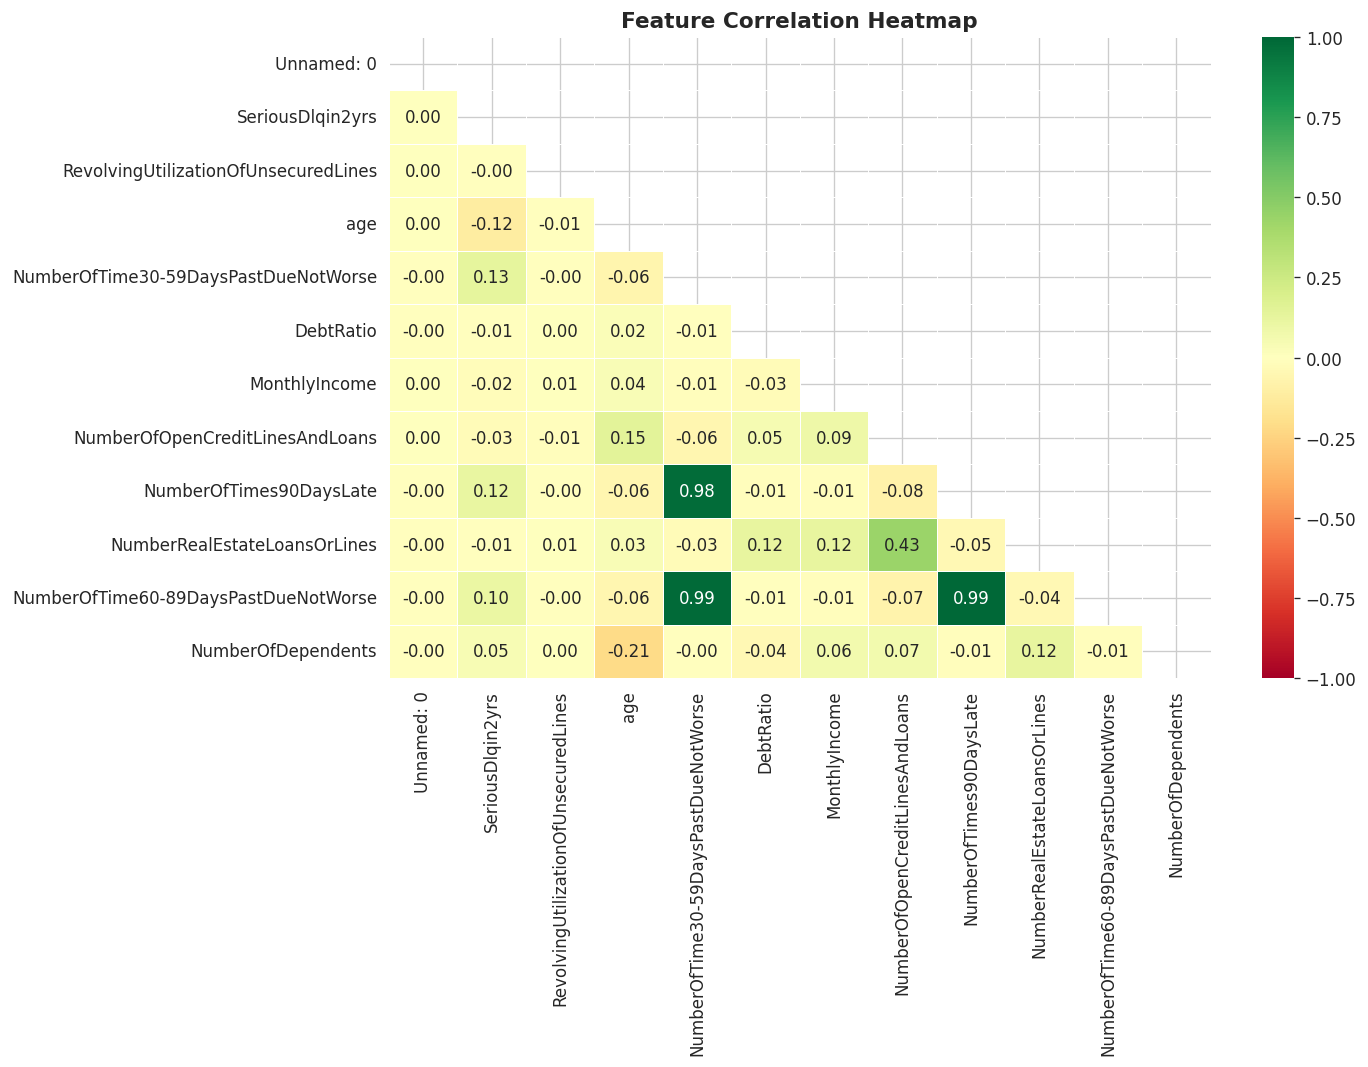

Dropping 'NumberOfTimes90DaysLate' (correlated with 'NumberOfTime30-59DaysPastDueNotWorse')
Dropping 'NumberOfTime60-89DaysPastDueNotWorse' (correlated with 'NumberOfTime30-59DaysPastDueNotWorse')
Dropping 'NumberOfTime60-89DaysPastDueNotWorse' (correlated with 'NumberOfTimes90DaysLate')

Remaining columns (10): ['Unnamed: 0', 'SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']


In [ ]:
corr = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_correlation.png', bbox_inches='tight')
plt.show()

# Remove features correlated above 0.80
THRESHOLD = 0.80
to_drop = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i,j]) >= THRESHOLD:
            to_drop.append(corr.columns[j])
            print(f"Dropping '{corr.columns[j]}' (correlated with '{corr.columns[i]}')")

to_drop = list(set(to_drop))
if to_drop:
    df = df.drop(columns=to_drop)
print(f"\nRemaining columns ({len(df.columns)}): {list(df.columns)}")

In [ ]:
# Fill MonthlyIncome with median (robust to extreme values)
median_income = df['MonthlyIncome'].median()
df['MonthlyIncome'].fillna(median_income, inplace=True)

# Fill NumberOfDependents with mode (most common value)
mode_dep = int(df['NumberOfDependents'].mode()[0])
df['NumberOfDependents'].fillna(mode_dep, inplace=True)

print(f"MonthlyIncome  → filled with median = ${median_income:,.2f}")
print(f"NumberOfDependents → filled with mode = {mode_dep}")
print(f"Missing values remaining: {df.isnull().sum().sum()}")

MonthlyIncome  → filled with median = $5,400.00
NumberOfDependents → filled with mode = 0
Missing values remaining: 0


In [ ]:
# Cap extreme outliers at the 99th percentile
for col_name in ['RevolvingUtilizationOfUnsecuredLines','DebtRatio','MonthlyIncome']:
    cap = df[col_name].quantile(0.99)
    df[col_name] = df[col_name].clip(upper=cap)
    print(f"{col_name} capped at {cap:,.2f}")

# Drop 'Unnamed: 0' column as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Convert to PySpark and rename target column to 'label'
df_spark = spark.createDataFrame(df)
df_spark = df_spark.withColumnRenamed('SeriousDlqin2yrs', 'label')
df_spark = df_spark.withColumn('label', col('label').cast('integer'))

print(f"\nData loaded into PySpark: {df_spark.count():,} rows x {len(df_spark.columns)} cols")
df_spark.printSchema()

RevolvingUtilizationOfUnsecuredLines capped at 1.09
DebtRatio capped at 4,979.04
MonthlyIncome capped at 23,000.00

Data loaded into PySpark: 150,000 rows x 9 cols
root
 |-- label: integer (nullable = true)
 |-- RevolvingUtilizationOfUnsecuredLines: double (nullable = true)
 |-- age: long (nullable = true)
 |-- NumberOfTime30-59DaysPastDueNotWorse: long (nullable = true)
 |-- DebtRatio: double (nullable = true)
 |-- MonthlyIncome: double (nullable = true)
 |-- NumberOfOpenCreditLinesAndLoans: long (nullable = true)
 |-- NumberRealEstateLoansOrLines: long (nullable = true)
 |-- NumberOfDependents: double (nullable = true)



In [ ]:
# All columns except the target are features (inputs)
feature_columns = [c for c in df_spark.columns if c != 'label']
print(f"Features ({len(feature_columns)}): {feature_columns}")

# Stage 1: Combine all feature columns into one vector column
assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol='raw_features',
    handleInvalid='skip'
)

# Stage 2: Scale features to similar range (mean=0, std=1)
# Important because features have very different scales (age vs income)
scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withMean=True, withStd=True
)

# Stage 3: Logistic Regression model
# threshold=0.3 means: if prob of default >= 30%, predict default
# (lower than 0.5 so we catch more defaulters — safer for credit risk)
lr = LogisticRegression(
    featuresCol='features', labelCol='label',
    maxIter=100, regParam=0.01,
    elasticNetParam=0.5, threshold=0.3
)

# Combine all 3 stages into one pipeline
pipeline = Pipeline(stages=[assembler, scaler, lr])
print("\nPipeline ready: VectorAssembler -> StandardScaler -> LogisticRegression")

Features (8): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']

Pipeline ready: VectorAssembler -> StandardScaler -> LogisticRegression


In [ ]:
# 80% for training (model learns from this)
# 20% for testing  (model is evaluated on this — data it has never seen)
# seed=42 makes the split reproducible (same result every run)
train_data, test_data = df_spark.randomSplit([0.80, 0.20], seed=42)

print(f"Training set : {train_data.count():,} rows (80%)")
print(f"Testing set  : {test_data.count():,} rows (20%)")

Training set : 119,856 rows (80%)
Testing set  : 30,144 rows (20%)


In [ ]:
print("Training the model...")
start = time.time()

trained_model = pipeline.fit(train_data)

elapsed = round(time.time() - start, 1)
print(f"Model trained in {elapsed} seconds!")

Training the model...
Model trained in 14.6 seconds!


In [ ]:
predictions = trained_model.transform(test_data)
print("Predictions generated. Sample of 10:")
predictions.select('label','prediction','probability').show(10, truncate=False)

Predictions generated. Sample of 10:
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0    |0.0       |[0.9711006810928384,0.028899318907161575]|
|0    |0.0       |[0.9714487952097757,0.028551204790224327]|
|0    |0.0       |[0.9711619143173099,0.028838085682690084]|
|0    |0.0       |[0.9716279120444726,0.02837208795552737] |
|0    |0.0       |[0.9714052466393371,0.02859475336066286] |
|0    |0.0       |[0.9714146921992066,0.02858530780079338] |
|0    |0.0       |[0.9718381474535899,0.028161852546410127]|
|0    |0.0       |[0.9720887215074733,0.027911278492526725]|
|0    |0.0       |[0.9715915192832639,0.028408480716736073]|
|0    |0.0       |[0.9718828632528789,0.02811713674712113] |
+-----+----------+-----------------------------------------+
only showing top 10 rows


In [ ]:
auc_score = BinaryClassificationEvaluator(
    labelCol='label', metricName='areaUnderROC').evaluate(predictions)

accuracy = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction',
    metricName='accuracy').evaluate(predictions)

precision = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction',
    metricName='weightedPrecision').evaluate(predictions)

recall = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction',
    metricName='weightedRecall').evaluate(predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction',
    metricName='f1').evaluate(predictions)

print("=" * 45)
print("   MODEL PERFORMANCE METRICS")
print("=" * 45)
print(f"  AUC-ROC   : {auc_score:.4f}  (0.5=random, 1.0=perfect)")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print("=" * 45)

   MODEL PERFORMANCE METRICS
  AUC-ROC   : 0.7943  (0.5=random, 1.0=perfect)
  Accuracy  : 93.23%
  Precision : 0.9081
  Recall    : 0.9323
  F1 Score  : 0.9014


In [ ]:
pred_pd = predictions.select('label','prediction').toPandas()
y_true  = pred_pd['label'].astype(int)
y_pred  = pred_pd['prediction'].astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['No Default','Default']))


Classification Report:
              precision    recall  f1-score   support

  No Default       0.93      1.00      0.96     28097
     Default       0.57      0.01      0.03      2047

    accuracy                           0.93     30144
   macro avg       0.75      0.51      0.50     30144
weighted avg       0.91      0.93      0.90     30144



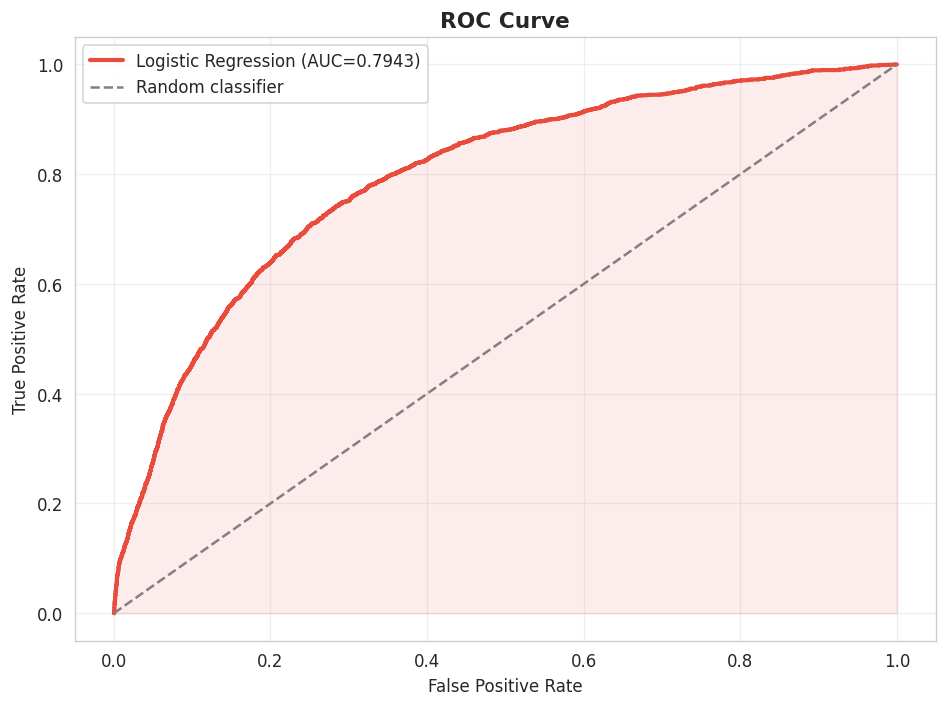

AUC = 0.7943


In [ ]:
get_prob = udf(lambda v: float(v[1]), FloatType())
prob_pd  = predictions.select(
    'label', get_prob('probability').alias('prob_default')).toPandas()

fpr, tpr, _ = roc_curve(prob_pd['label'], prob_pd['prob_default'])
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2.5,
         label=f'Logistic Regression (AUC={roc_auc_val:.4f})')
plt.plot([0,1],[0,1], 'gray', linestyle='--', lw=1.5, label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_roc_curve.png', bbox_inches='tight')
plt.show()
print(f"AUC = {roc_auc_val:.4f}")

Feature Coefficients (positive = increases default risk):
                             Feature  Coefficient
RevolvingUtilizationOfUnsecuredLines     0.807946
NumberOfTime30-59DaysPastDueNotWorse     0.079596
     NumberOfOpenCreditLinesAndLoans     0.054659
                  NumberOfDependents     0.025015
        NumberRealEstateLoansOrLines     0.000000
                           DebtRatio     0.000000
                       MonthlyIncome    -0.011991
                                 age    -0.137218

Model Intercept: -2.9970


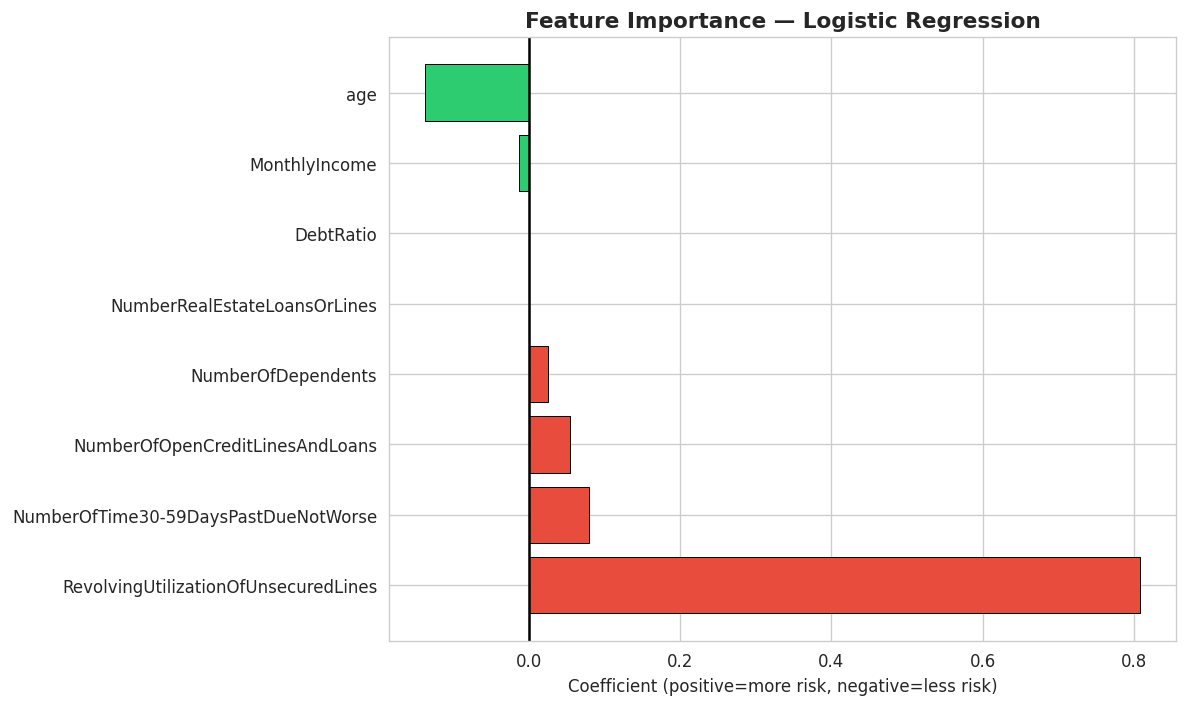

In [ ]:
lr_model = trained_model.stages[-1]
feat_imp = pd.DataFrame({
    'Feature'    : feature_columns,
    'Coefficient': lr_model.coefficients.toArray()
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print("Feature Coefficients (positive = increases default risk):")
print(feat_imp.to_string(index=False))
print(f"\nModel Intercept: {lr_model.intercept:.4f}")

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in feat_imp['Coefficient']]
plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Coefficient'],
         color=colors, edgecolor='black', linewidth=0.6)
plt.axvline(0, color='black', lw=1.5)
plt.xlabel('Coefficient (positive=more risk, negative=less risk)')
plt.title('Feature Importance — Logistic Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_feature_importance.png', bbox_inches='tight')
plt.show()

In [ ]:
results = []
for thresh in [0.2, 0.3, 0.4, 0.5]:
    y_pred_t = (prob_pd['prob_default'] >= thresh).astype(int)
    r = classification_report(prob_pd['label'].astype(int), y_pred_t, output_dict=True)
    results.append({
        'Threshold'          : thresh,
        'Recall (Default)'   : round(r.get('1',{}).get('recall', 0), 3),
        'Precision (Default)': round(r.get('1',{}).get('precision', 0), 3),
        'F1 (Default)'       : round(r.get('1',{}).get('f1-score', 0), 3),
        'Accuracy'           : round(r['accuracy'], 3)
    })

results_df = pd.DataFrame(results)
print("Threshold Comparison:")
print(results_df.to_string(index=False))
print("\nLower threshold = catches more defaulters (higher Recall)")
print("but also more false alarms (lower Precision).")
print("We use 0.3 to prioritise catching defaulters in credit risk.")

Threshold Comparison:
 Threshold  Recall (Default)  Precision (Default)  F1 (Default)  Accuracy
       0.2             0.269                0.288         0.278     0.905
       0.3             0.015                0.566         0.029     0.932
       0.4             0.015                0.566         0.029     0.932
       0.5             0.015                0.566         0.029     0.932

Lower threshold = catches more defaulters (higher Recall)
but also more false alarms (lower Precision).
We use 0.3 to prioritise catching defaulters in credit risk.


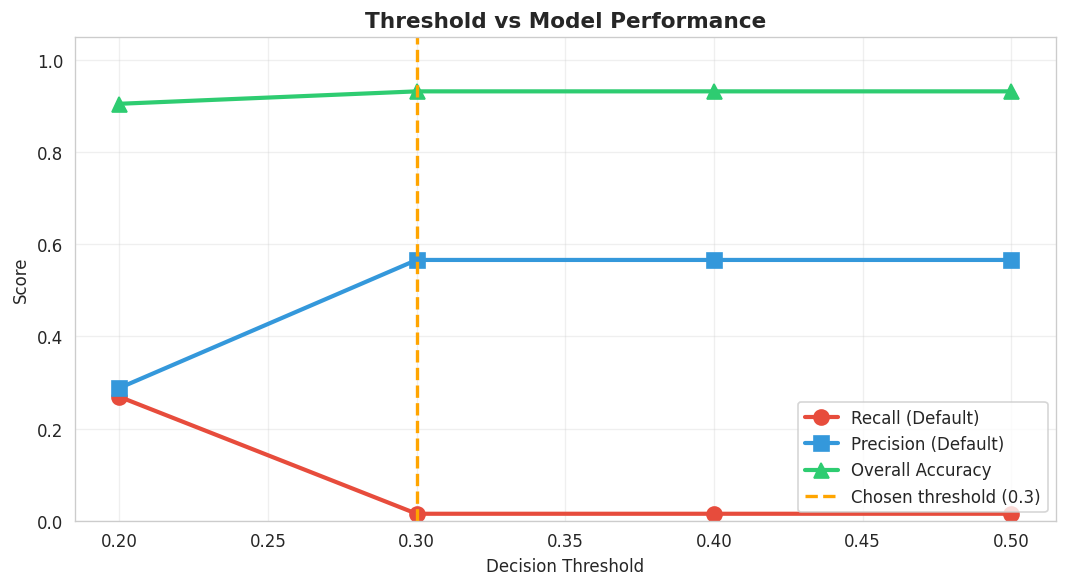

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(results_df['Threshold'], results_df['Recall (Default)'],
         'o-', color='#e74c3c', lw=2.5, ms=9, label='Recall (Default)')
plt.plot(results_df['Threshold'], results_df['Precision (Default)'],
         's-', color='#3498db', lw=2.5, ms=9, label='Precision (Default)')
plt.plot(results_df['Threshold'], results_df['Accuracy'],
         '^-', color='#2ecc71', lw=2.5, ms=9, label='Overall Accuracy')
plt.axvline(0.3, color='orange', linestyle='--', lw=2, label='Chosen threshold (0.3)')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold vs Model Performance', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_threshold.png', bbox_inches='tight')
plt.show()

In [ ]:
MODEL_PATH = f'{PROJECT_FOLDER}/credit_score_model'

if os.path.exists(MODEL_PATH):
    shutil.rmtree(MODEL_PATH)

trained_model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")

Model saved to: /content/drive/MyDrive/Colab Notebooks/CreditScoreProject/credit_score_model


In [ ]:
reloaded_model = PipelineModel.load(MODEL_PATH)
print("Model reloaded successfully!")
print(f"Stages: {[type(s).__name__ for s in reloaded_model.stages]}")

Model reloaded successfully!
Stages: ['VectorAssembler', 'StandardScalerModel', 'LogisticRegressionModel']


Credit Assessment Results:

                          Default_Probability    Risk Decision
Borrower A (High Risk)                  0.371  MEDIUM  DECLINE
Borrower B (Low Risk)                   0.025     LOW  APPROVE
Borrower C (Medium Risk)                0.090     LOW  APPROVE


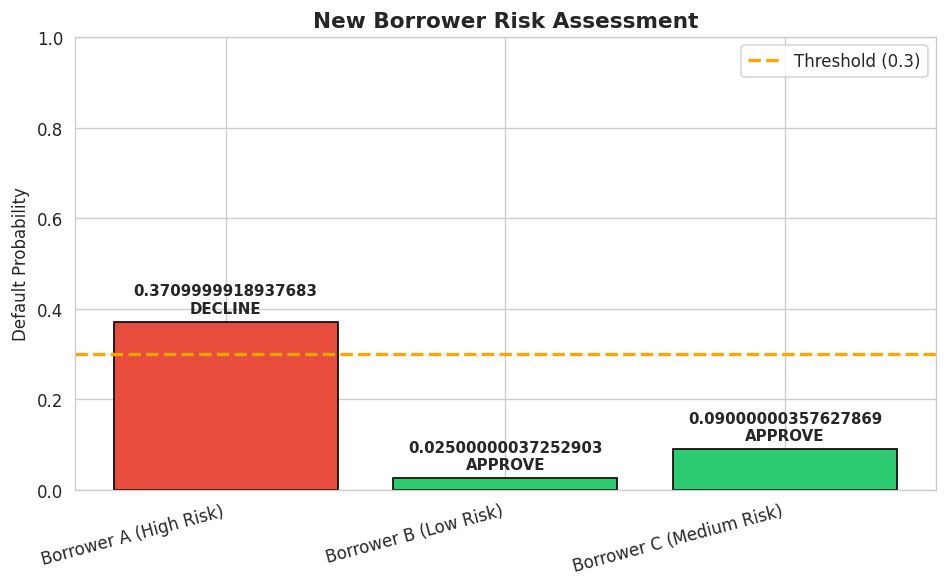

In [ ]:
new_borrowers = pd.DataFrame({
    'RevolvingUtilizationOfUnsecuredLines' : [1.20,  0.08, 0.55],
    'age'                                  : [32,    58,   42],
    'NumberOfTime30-59DaysPastDueNotWorse' : [15,     0,    2],
    'DebtRatio'                            : [1.00,  0.15, 0.45],
    'MonthlyIncome'                        : [15000,  9000, 5500],
    'NumberOfOpenCreditLinesAndLoans'      : [9,    3,    6],
    'NumberRealEstateLoansOrLines'         : [2,     2,    1],
    'NumberOfDependents'                   : [1,     2,    3]
})

cols_to_keep = [c for c in new_borrowers.columns if c in df_spark.columns]
new_spark = spark.createDataFrame(new_borrowers[cols_to_keep])

results_inf = reloaded_model.transform(new_spark)

get_p = udf(lambda v: float(v[1]), FloatType())
out = results_inf.select(
    get_p('probability').alias('Default_Probability'), 'prediction').toPandas()

out['Default_Probability'] = out['Default_Probability'].round(3)
out['Decision'] = out['prediction'].map({0.0:'APPROVE', 1.0:'DECLINE'})
out['Risk']     = out['Default_Probability'].apply(
    lambda p: 'HIGH' if p>=0.5 else ('MEDIUM' if p>=0.3 else 'LOW'))
out.index = ['Borrower A (High Risk)','Borrower B (Low Risk)','Borrower C (Medium Risk)']

print("Credit Assessment Results:\n")
print(out[['Default_Probability','Risk','Decision']].to_string())

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if d==1.0 else '#2ecc71' for d in out['prediction']]
bars = plt.bar(out.index, out['Default_Probability'], color=colors, edgecolor='black')
plt.axhline(0.3, color='orange', linestyle='--', lw=2, label='Threshold (0.3)')
plt.title('New Borrower Risk Assessment', fontsize=13, fontweight='bold')
plt.ylabel('Default Probability')
plt.ylim(0, 1)
plt.xticks(rotation=15, ha='right')
plt.legend()
for bar, (_, row) in zip(bars, out.iterrows()):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f"{row['Default_Probability']}\n{row['Decision']}",
             ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROJECT_FOLDER}/chart_inference.png', bbox_inches='tight')
plt.show()

In [ ]:
print("   CREDIT SCORE PREDICTION SUMMARY")
print("=" * 58)
print(f"  Dataset    : Give Me Some Credit (Kaggle)")
print(f"  Records    : 150,000 borrowers")
print(f"  Features   : {len(feature_columns)}")
print(f"  Algorithm  : Logistic Regression (PySpark MLlib)")
print(f"  Split      : 80% train / 20% test")
print()
print(f"  AUC-ROC   : {auc_score:.4f}")
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  Threshold : 0.3 (optimised for credit risk)")
print()
print(f"  Model saved to: {MODEL_PATH}")
print()
print("  Charts saved to Google Drive:")
for c in ['chart_class_distribution','chart_missing_values',
          'chart_distributions','chart_correlation',
          'chart_roc_curve','chart_feature_importance',
          'chart_threshold','chart_inference']:
    print(f"    - {c}.png")

spark.stop()
print("\nSpark stopped")

   CREDIT SCORE PREDICTION SUMMARY
  Dataset    : Give Me Some Credit (Kaggle)
  Records    : 150,000 borrowers
  Features   : 8
  Algorithm  : Logistic Regression (PySpark MLlib)
  Split      : 80% train / 20% test

  AUC-ROC   : 0.7943
  Accuracy  : 93.23%
  Precision : 0.9081
  Recall    : 0.9323
  F1 Score  : 0.9014
  Threshold : 0.3 (optimised for credit risk)

  Model saved to: /content/drive/MyDrive/Colab Notebooks/CreditScoreProject/credit_score_model

  Charts saved to Google Drive:
    - chart_class_distribution.png
    - chart_missing_values.png
    - chart_distributions.png
    - chart_correlation.png
    - chart_roc_curve.png
    - chart_feature_importance.png
    - chart_threshold.png
    - chart_inference.png

Spark stopped
